In [3]:
using PhDProject

In [4]:
using LinearAlgebra
using SparseArrays
using Kronecker
using Plots

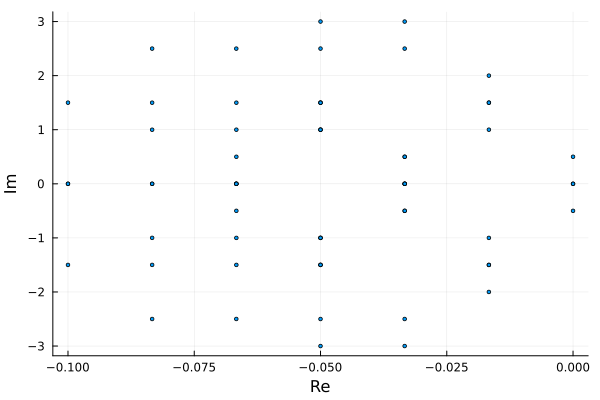

In [17]:
function spin_operators(M)

    # Build sparse matrix version of basic spin (Pauli) operators :
    sp = spdiagm(2,2,1=>ones(1))
    sm = spdiagm(2,2,-1=>ones(1))
    sz = spdiagm(2,2,0=>[1;-1]);
    num = spdiagm(2,2,0=>[0;1])
    # Notice there are NO factors of (1/2) for spin-1/2 included here.

    # Construct spin operators for each spin in the full Hilbert space :
    Sz = Vector{Any}(undef, M)
    Sp = Vector{Any}(undef, M)
    Sm = Vector{Any}(undef, M)
    Num = Vector{Any}(undef,M)
    for m=1:M
        Sz[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sz),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sp[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sp),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sm[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sm),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Num[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),num),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
    end
    return Sz,Sp,Sm,Num
end

function PhDProject.rmult(A)
    """
    Super-operator representing right-multiplication on a vectorised density matrix
    """
    d = size(A)[1]
    Id = 1.0*Matrix(I, d, d)
    return kronecker(transpose(A),Id)
end
function PhDProject.lmult(A)
    """
    Super-operator representing left-multiplication on a vectorised density matrix
    """
    d = size(A)[1]
    Id = 1.0*Matrix(I, d, d)
    return kronecker(Id,A)
end

#parameters
N_ring = 3
J = 0.5
B = 0.5
Δ = 0
Γ = 0.1
β = 1000


#basic objects
nbar = (exp(β*B)-1)^(-1)
d = 2^N_ring
σz,σp,σm,Num = spin_operators(N_ring)
σz,σp,σm = Matrix.(σz),Matrix.(σp),Matrix.(σm)
σx = σp .+ σm
σy = -im.*(σp .- σm)
σz = Matrix.(σz)
Id = 1* Matrix(I, d, d)
Left_vac = PhDProject.vectorise_mat(Id)

#Build isolated hamiltonian
H = complex(zeros(d,d))
for i=1:N_ring
    if i != N_ring
        # H+= J*σx[i]*σx[i+1]
        # H+= J*σy[i]*σy[i+1]
        # H+= Δ*σz[i]*σz[i+1]
        H += J*σp[i]*σm[i+1]
        H += J*σm[i]*σp[i+1]
        H += Δ*σz[i]*σz[i+1]
    else
        H += J*σp[i]*σm[1]
        H += J*σm[i]*σp[1]
        H += Δ*σz[i]*σz[1]
    end
    H+= B*σz[i]
end

#Build Lindbladian
L_unitary = -im*(PhDProject.lmult(H)- PhDProject.rmult(H))
emission = Γ*(nbar+1)*(PhDProject.lmult(σm[N_ring])*PhDProject.rmult(σp[N_ring])-(1/2)*PhDProject.rmult(σp[N_ring]*σm[N_ring]) - (1/2)*PhDProject.lmult(σp[N_ring]*σm[N_ring]))
absorption = Γ*nbar*(PhDProject.lmult(σp[N_ring])*PhDProject.rmult(σm[N_ring])-(1/2)*PhDProject.rmult(σm[N_ring]*σp[N_ring]) - (1/2)*PhDProject.lmult(σm[N_ring]*σp[N_ring]))
L_markovian = L_unitary + emission + absorption


L_eigenvectors = eigen(L_markovian).vectors
L_eigenvalues = eigen(L_markovian).values

#Build map
times = range(start=0,stop=100,step=0.1)
Λ_vec = [exp(L_markovian*t) for t in times]

Λ_eigenvalues = complex(zeros(length(times),2^(2*N_ring)))
[Λ_eigenvalues[i,:] = eigen(Λ_vec[i]).values for i=1:length(times)]

Plots.scatter(real.(L_eigenvalues),imag.(L_eigenvalues),xlabel = "Re",
    ylabel = "Im",label = "",ms=2)




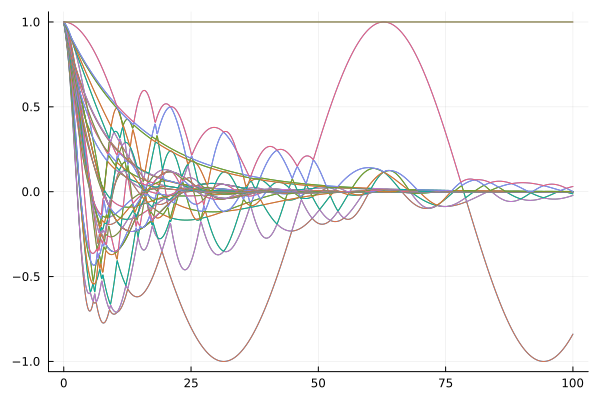

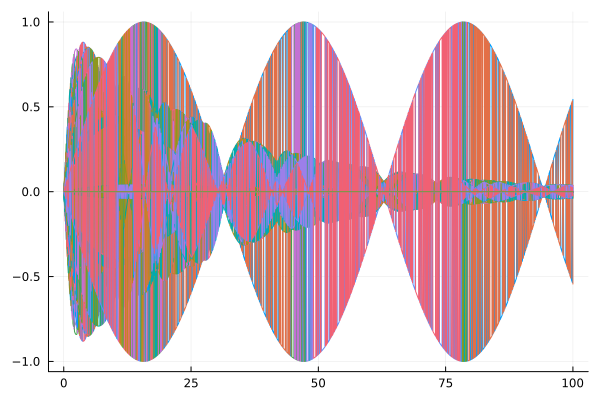

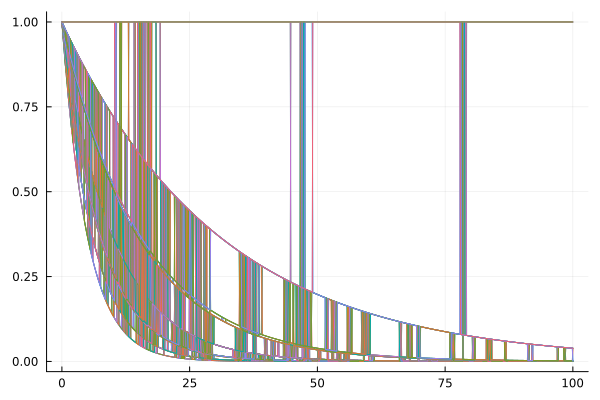

In [12]:
display(Plots.plot(times,real.(Λ_eigenvalues),label=false))
display(Plots.plot(times,imag.(Λ_eigenvalues),label=false))
display(Plots.plot(times,abs.(Λ_eigenvalues),label=false))

In [16]:
# # i = 13
# Plots.scatter(real.(Λ_eigenvalues[i,:]),imag.(Λ_eigenvalues[i,:]),xlabel = "Re",
# #     ylabel = "Im",label = "",ms=2)

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(Λ_eigenvalues[i,:]),imag.(Λ_eigenvalues[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum.gif")
